In [1]:
import sys
import introns
import pandas as pd
import numpy as np
import importlib
importlib.reload(introns)
import matplotlib.pyplot as plt
from termcolor import colored
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
genome, genes = introns.create('/home/halakuc/genomy/21_11_03_manual_alignment_for_euglena_network/allignmenty_all_2.fasta',
                               '/home/halakuc/genomy/21_11_03_manual_alignment_for_euglena_network/allignmenty_all_2.gff',
                               'manual')

EL|STRG.5724.1|scaffold_3542:6373-8348 132 562
CCATG ATCCG CCCCC GAAGG
EL|STRG.5724.1|scaffold_3542:6373-8348 637 884
GGACC GCCCG ACACC AGAGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 636 883
CGGAC CGCCC GACAC CAGAG
left 2 EL|STRG.5724.1|scaffold_3542:6373-8348 635 882
CCGGA CCGCC CGACA CCAGA
left 3 EL|STRG.5724.1|scaffold_3542:6373-8348 634 881
ACCGG ACCGC CCGAC ACCAG
EL|STRG.5724.1|scaffold_3542:6373-8348 983 1286
AAACG GTCCT TTCAG GGCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 982 1285
GAAAC GGTCC CTTCA GGGCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 984 1287
AACGG TCCTG TCAGG GCGGT
EL|STRG.5724.1|scaffold_3542:6373-8348 1444 1916
CCTGG GTTTT TCCAG GTCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1443 1915
ACCTG GGTTT TTCCA GGTCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1445 1917
CTGGG TTTTC CCAGG TCGGG
right 2 EL|STRG.5724.1|scaffold_3542:6373-8348 1446 1918
TGGGT TTTCC CAGGT CGGGA
EH|STRG.10125.1|scaffold_4676:26801-34772 584 1350
TCATG CCCCA CCACG AGCTG
lef

In [8]:
k_labels = ['Intron K', 'Inron K', 'Intron K (EL, EG)', 'Intron K ', 'Exon K', "Intron K (5' partial)"]
nk_labels = ['Intron N', 'Intron N (EH)', 'Intron NK', 'Intron NK ', 'Intron N ', 'Intron NK (polimorfizm)']  
i_labels = ['Intron I', 'Intron I ', 'I', 'Intron P']
label_dict = {}
for i in k_labels:
    label_dict[i] = 'intron_K'
for i in nk_labels:
    label_dict[i] = 'intron_NK'
for i in i_labels:
    label_dict[i] = 'intron_I'
    
from Bio import SeqIO
count = {}

with open('/home/halakuc/genomy/21_11_03_manual_alignment_for_euglena_network/allignmenty_all_2.gb') as gb_file:
    for record in SeqIO.parse(gb_file, "genbank"):
        #print(record)
        gene_name = record.name
        source = 'manual_annotation'
        feature, start, end, score, strand, frame, attribute = '', '', '', '1000', '+', '.', '.'
        gene_start, gene_end = 1000000, 0
        exons = []
        for feature_listed in record.features:
            feature = feature_listed.type
            start, end = int(feature_listed.location.start.position), int(feature_listed.location.end.position)
            try:
                label = feature_listed.qualifiers['label'][0]
            except KeyError as exc:
                print(feature_listed)
                continue
            if label in label_dict.keys():
                label = label_dict[label]
                gene_obj = genes[gene_name]
            try:
                intron_obj = gene_obj.introns_dict[(start, end)]
                intron_obj.add_manual_annotation(label, start, end)
                if label not in count:
                    count[label] = 1
                else:
                    count[label] += 1
            except KeyError:
                pass

print(count)

{'intron_NK': 430, 'intron_K': 368, 'intron_I': 12}


In [9]:
introns_NK, introns_K, introns_I = [], [], []
genes_K, genes_NK, genes_both = [], [], []
exons = []

for gene_name, gene_obj in genes.items():
    for intron in gene_obj.introns:
        intron.add_test_annotation()
        if intron.man_annotation == 'intron_NK':
            introns_NK.append(intron)
        if intron.man_annotation == 'intron_K':
            introns_K.append(intron)
        if intron.man_annotation == 'intron_I':
            introns_I.append(intron)
    for exon in gene_obj.exons:
        exons.append(exon)
print('Intron_NK', len(introns_NK))
print('Intron_K', len(introns_K))
print('intron_I', len(introns_I))
print(len(introns_I + introns_K + introns_NK))
print('exon', len(exons))

Intron_NK 430
Intron_K 368
intron_I 12
810
exon 913


In [4]:
introns_seqs, introns_classes, introns_characteristics = [], [], []
f = open("introns_for_classifier_training.fasta", 'r')
for l in f.readlines():
    if l.startswith(">"):
        #print("nazwa", l.split()[-1])
        cl = 1 if l.split()[-1].split("_")[-1]=='NK' else 0
        introns_classes.append(cl)
    else:
        introns_seqs.append(l[1:])
        introns_characteristics.append(list(introns.compute_intron_characteristics(l)))

print(len(introns_classes), len(introns_seqs), len(introns_characteristics))

801 801 801


In [19]:
baseY = {'C', 'T'}
baseR = {'A', 'G'}

columns=['intron_obj', 'eY| i', 'e |Ri', 'C-G', 'A-T', 'G-C', 'CAG - CGT', 'iY| e', 'i |Re', 'klasa']
introns_set = pd.DataFrame(columns = columns)

introns_variants, true_classes = [], []
# introny niekonwencjonalne = 1
for intron in introns_NK:  
    intron_df = pd.DataFrame([[intron, *introns.compute_intron_characteristics(intron), 1]], columns=columns)
    introns_set = introns_set.append(intron_df, ignore_index=True)
    introns_variants.append([introns.compute_intron_characteristics(i) for i in intron.variations+[intron]])
    true_classes.append(1)

# inne niż niekonwencjonalne = 0
for intron in introns_K+introns_I:
    intron_df = pd.DataFrame([[intron, *introns.compute_intron_characteristics(intron), 0]], columns=columns)
    introns_set = introns_set.append(intron_df, ignore_index=True)
    introns_variants.append([introns.compute_intron_characteristics(i) for i in intron.variations])
    true_classes.append(0)
print(len(introns_variants), len(true_classes))
introns_obj = introns_set['intron_obj']
introns_set.drop('intron_obj', axis=1, inplace = True)
columns = introns_set.columns
introns_set = introns_set.astype('int')
print(introns_set)

810 810
     eY| i  e |Ri  C-G  A-T  G-C  CAG - CGT  iY| e  i |Re  klasa
0        0      0    1    1    1          1      0      0      1
1        0      1    0    0    0          0      0      1      1
2        0      1    1    0    0          0      0      0      1
3        0      1    1    0    0          0      0      0      1
4        0      1    0    0    0          0      0      0      1
..     ...    ...  ...  ...  ...        ...    ...    ...    ...
805      1      1    0    0    0          0      1      0      0
806      0      1    1    0    1          0      0      1      0
807      0      1    1    1    1          1      0      1      0
808      1      1    1    0    0          0      1      0      0
809      0      1    0    0    0          0      0      1      0

[810 rows x 9 columns]


In [20]:
columns=['eY| i', 'e |Ri', 'C-G', 'A-T', 'G-C', 'CAG - CGT', 'iY| e', 'i |Re']#, 'klasa']
introns_set = pd.DataFrame(introns_characteristics, columns = columns)
introns_set['klasa'] = introns_classes

print(introns_set)

     eY| i  e |Ri  C-G  A-T  G-C  CAG - CGT  iY| e  i |Re  klasa
0        1      1    0    0    0          0      0      0      0
1        0      1    0    0    0          0      1      0      0
2        1      1    1    0    0          0      1      0      0
3        1      0    0    0    0          0      1      0      0
4        1      1    0    0    0          0      0      0      0
..     ...    ...  ...  ...  ...        ...    ...    ...    ...
796      1      0    0    0    0          0      0      0      1
797      1      1    0    0    0          0      0      1      1
798      1      0    0    0    1          0      1      1      1
799      1      0    0    0    0          0      1      0      1
800      0      0    1    0    0          0      1      1      1

[801 rows x 9 columns]


In [21]:
# uczenie klasyfikatora
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import pickle


i_s = introns_set.sample(frac=1)

clf = GaussianProcessClassifier(1.0 * RBF(1.0))
clf.fit(i_s[i_s.columns[:-1]].values, i_s[i_s.columns[-1]].values)

filename = 'finalized_model_2.sav'
pickle.dump(clf, open(filename, 'wb'))

In [22]:
import pickle

filename = 'finalized_model_2.sav'

loaded_model = pickle.load(open(filename, 'rb'))
print(type(loaded_model))
result = loaded_model.predict(np.array(i_s.iloc[5][:-1]).reshape(1, -1))
print(result[0])

<class 'sklearn.gaussian_process._gpc.GaussianProcessClassifier'>
1


# Zobaczmy jak działa (i czy wogle)

In [30]:
import sys
import introns
import pandas as pd
import numpy as np
import importlib
importlib.reload(introns)
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
%%time

genome, genes = introns.create('/home/halakuc/genomy/21_11_03_manual_alignment_for_euglena_network/allignmenty_all_2.fasta',
                               '/home/halakuc/genomy/21_11_03_manual_alignment_for_euglena_network/allignmenty_all_2.gff',
                               'manual')
#genome, genes = create('/mnt/archive/euglena_genomy/longa/longa_rascaf.fasta', '/mnt/archive/euglena_genomy/longa/longa_stringtie_strand_informed.gtf')
introns.predict_all_introns(genes)
print(len(genome), len(genes))

EL|STRG.5724.1|scaffold_3542:6373-8348 132 562
CCATG ATCCG CCCCC GAAGG
EL|STRG.5724.1|scaffold_3542:6373-8348 637 884
GGACC GCCCG ACACC AGAGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 636 883
CGGAC CGCCC GACAC CAGAG
left 2 EL|STRG.5724.1|scaffold_3542:6373-8348 635 882
CCGGA CCGCC CGACA CCAGA
left 3 EL|STRG.5724.1|scaffold_3542:6373-8348 634 881
ACCGG ACCGC CCGAC ACCAG
EL|STRG.5724.1|scaffold_3542:6373-8348 983 1286
AAACG GTCCT TTCAG GGCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 982 1285
GAAAC GGTCC CTTCA GGGCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 984 1287
AACGG TCCTG TCAGG GCGGT
EL|STRG.5724.1|scaffold_3542:6373-8348 1444 1916
CCTGG GTTTT TCCAG GTCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1443 1915
ACCTG GGTTT TTCCA GGTCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1445 1917
CTGGG TTTTC CCAGG TCGGG
right 2 EL|STRG.5724.1|scaffold_3542:6373-8348 1446 1918
TGGGT TTTCC CAGGT CGGGA
EH|STRG.10125.1|scaffold_4676:26801-34772 584 1350
TCATG CCCCA CCACG AGCTG
lef

In [26]:
#%%time


def create_r(genome, genes, genes_data_type):
    genome_eug = introns.read_genome(genome)
    genes_eug = read_genes_r(genes, genes_data_type)
    for name, gene in list(genes_eug.items()):
        gene.add_exons()
        gene.extract_sequence(genome_eug)
        gene.create_introns()
        #gene.predict_introns()
    introns.predict_all_introns(genes_eug)
    return genome_eug, genes_eug

def read_genes_r(filename, data_type):
    valid_data_type = {'stringtie'}
    if data_type not in valid_data_type:
        raise ValueError("read_genes: data_type must be one of {}.".format(valid_data_type))
    genes = {}  # slownik genow
    gene, exon = None, None
    exons = []
    prev = None
    for line in introns.process_file(filename):
        if line[0] == '#':
            continue
        if line[2] == 'transcript':
            if line[6] in {"-", "+"}:
                gene_name = line[11].strip('";"')
                gene = introns.Gene(line[0], line[3] - 1, line[4], name=gene_name, strand=line[6], exons=[])
                genes[gene_name] = gene
            else:
                gene = None
        elif line[2] == 'exon':
            if line[6] in {"-", "+"}:
                gene_name = line[11].strip('";"')
                gene = genes[gene_name]
                exon = introns.Exon(line[0], line[3] - 1, line[4], strand=line[6], gene=gene)
                gene.working_exons.append(exon)
    return genes

genome, genes = create_r('/mnt/archive/euglena_genomy/longa/longa_rascaf.fasta', '/mnt/archive/euglena_genomy/longa/longa_stringtie_strand_informed.gtf', "stringtie")
print(len(genome), len(genes))

TypeError: __init__() got an unexpected keyword argument 'exons'

In [ ]:
print(1)

In [ ]:
print(genes)

In [27]:
for gene_name in ['STRG.33.1', 'STRG.33.2', 'STRG.33.3', 'STRG.33.4', 'STRG.33.5']:
    gene = genes[gene_name]
    print(genes[gene_name])
    for intron in gene.introns:
        print('\t', intron)
        print('\t', len(intron.variations))
        print(intron.ML_best_conv_version, intron.ML_best_conv_version.ML_is_nonconventional, intron.ML_best_conv_version.ML_nonconv_proba)
        print(intron.ML_best_nonconv_version, intron.ML_best_nonconv_version.ML_is_nonconventional, intron.ML_best_nonconv_version.ML_nonconv_proba)


KeyError: 'STRG.33.1'

In [28]:
conv, nconv, inter = 0, 0, 0
conv_scores, nconv_scores = [], []

cnt = 0
for name, gene in genes.items():
    for intron in gene.introns:
        c, nc = intron.ML_best_conv_version.ML_is_nonconventional, intron.ML_best_nonconv_version.ML_is_nonconventional
        conv_scores.append(intron.ML_best_conv_version.ML_nonconv_proba)
        nconv_scores.append(intron.ML_best_nonconv_version.ML_nonconv_proba)
        if c and nc:
            nconv += 1
        elif not c and nc:
            inter += 1
        elif not c and not nc:
            conv += 1
        else:
            print(intron)
print(conv, nconv, inter)

AttributeError: 'NoneType' object has no attribute 'ML_is_nonconventional'

In [ ]:
import matplotlib.pyplot as plt
plt.hist(conv_scores, color='b', alpha=0.6)
plt.hist(nconv_scores, color='r', alpha=0.6)
plt.show()

In [ ]:
conv, nconv = 0, 0
for name, gene in genes.items():
    for i in gene.introns:
        c = i.ML_is_nonconventional
        if c:
            nconv += 1
        else:
            conv += 1
print(conv, nconv)

In [ ]:
for name, gene in genes.items():
    for i in gene.introns:
        if i.ML_best_conv_version == i.ML_best_nonconv_version and len(i.variations)>1:
            print(i)
            print(i.variations)
            print([v.sequence for v in i.variations])
            print([v.ML_nonconv_proba for v in i.variations])
            print("\n")

In [ ]:
for name, gene in genes.items():
    for i in gene.introns:
        print("manual annotation:", i.man_annotation)
        print("pred", i.ML_nonconv_proba, "\tpred v", [v.ML_nonconv_proba for v in i.variations])

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
bar1 = "Czas przed śmiganiem: 12min 59s"
bar2 = "Czas po pierwszym śmignięciu: 40.5 s"
bar3 = "Czas po drugim śmiganiu: 16.5 s"
t1, t2, t3 = 12*60+59, 40.5, 16.5
plt.bar([bar1,bar2, bar3], [t1, t2, t3])
plt.title("Poprawa czasu obliczeń: %d-krotna" %(t1/t3))
plt.ylabel("Czas obliczeń [s]")
plt.show()

In [ ]:
import pickle

loaded_model = pickle.load(open('finalized_model.sav', 'rb'))

In [1]:
import sys
import introns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
importlib.reload(introns)
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
%%time

def create(genome,genes):
    genome_eug = introns.read_genome(genome)
    genes_eug = read_genes(genes)
    for name, gene in list(genes_eug.items()):
        print(name)
        gene.add_exons()
        gene.extract_sequence(genome_eug)
        %time
        gene.create_introns()
        %time
        gene.predict_introns()
    return genome_eug, genes_eug


def read_genes(filename):
    genes = {}  # slownik genow
    gene, exon = None, None
    exons = []
    prev = None
    for line in introns.process_file(filename):
        if line[0] == '#':
            continue
        if line[2] == 'transcript':
            if line[6] in {"-", "+"}:
                gene_name = line[8]
                gene = introns.Gene(line[0], line[3] - 1, line[4], name=gene_name, strand=line[6], exons=[])
                genes[gene_name] = gene
            else:
                gene = None
        elif line[2] == 'exon':
            if line[6] in {"-", "+"}:
                exon = introns.Exon(line[0], line[3] - 1, line[4], strand=line[6], gene=gene)
                gene.working_exons.append(exon)
    return genes


genome, genes = create('/home/halakuc/genomy/21_11_03_manual_alignment_for_euglena_network/allignmenty_all_2.fasta', '/home/halakuc/genomy/21_11_03_manual_alignment_for_euglena_network/allignmenty_all_2.gff')

print(len(genome), len(genes))

EL|STRG.5724.1|scaffold_3542:6373-8348
CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 9.78 µs
EL|STRG.5724.1|scaffold_3542:6373-8348 132 562
CCATG ATCCG CCCCC GAAGG
EL|STRG.5724.1|scaffold_3542:6373-8348 637 884
GGACC GCCCG ACACC AGAGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 636 883
CGGAC CGCCC GACAC CAGAG
left 2 EL|STRG.5724.1|scaffold_3542:6373-8348 635 882
CCGGA CCGCC CGACA CCAGA
left 3 EL|STRG.5724.1|scaffold_3542:6373-8348 634 881
ACCGG ACCGC CCGAC ACCAG
EL|STRG.5724.1|scaffold_3542:6373-8348 983 1286
AAACG GTCCT TTCAG GGCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 982 1285
GAAAC GGTCC CTTCA GGGCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 984 1287
AACGG TCCTG TCAGG GCGGT
EL|STRG.5724.1|scaffold_3542:6373-8348 1444 1916
CCTGG GTTTT TCCAG GTCGG
left 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1443 1915
ACCTG GGTTT TTCCA GGTCG
right 1 EL|STRG.5724.1|scaffold_3542:6373-8348 1445 1917
CTGGG TTTTC CCAGG TCGGG
right 2 EL|STRG.5724.1|scaffold_3542:6373-8348 1446 1918

In [3]:
introns.predict_all_introns(genes)

2570 2570


In [4]:
conv, nconv = 0, 0
for name, gene in genes.items():
    for intron in gene.introns:
        if intron.ML_is_nonconventional: nconv+=1
        else: conv +=1

In [5]:
podstawowe = []
podstawowe_konw = []
podstawowe_niekonw = []
wszystkie_wersje = []
wszystkie_wersje_konw = []
wszystkie_wersje_niekonw = []
najlepsze_nconv_wersje = []
najlepsze_conv_wersje = []
wersje_konwencjonalne = []
wersje_niekonwencjonalne = []

for name, gene in genes.items():
    for intron in gene.introns:
        podstawowe.append(intron.ML_nonconv_proba)
        najlepsze_nconv_wersje.append(intron.ML_best_nonconv_version.ML_nonconv_proba)
        najlepsze_conv_wersje.append(intron.ML_best_conv_version.ML_nonconv_proba)
        wszystkie_wersje += [i.ML_nonconv_proba for i in intron.variations]
        
        if intron.ML_is_nonconventional:
            podstawowe_niekonw.append(intron.ML_nonconv_proba)
            wszystkie_wersje_niekonw += [i.ML_nonconv_proba for i in intron.variations]
            #wersje_niekonwencjonalne += [i.ML_nonconv_proba for i in intron.variations]
        else:
            podstawowe_konw.append(intron.ML_nonconv_proba)
            wszystkie_wersje_konw += [i.ML_nonconv_proba for i in intron.variations]
            #wersje_konwencjonalne += [i.ML_nonconv_proba for i in intron.variations]
            

print(len(podstawowe), len(wszystkie_wersje), len(najlepsze_nconv_wersje), len(najlepsze_conv_wersje))

816 1754 816 816


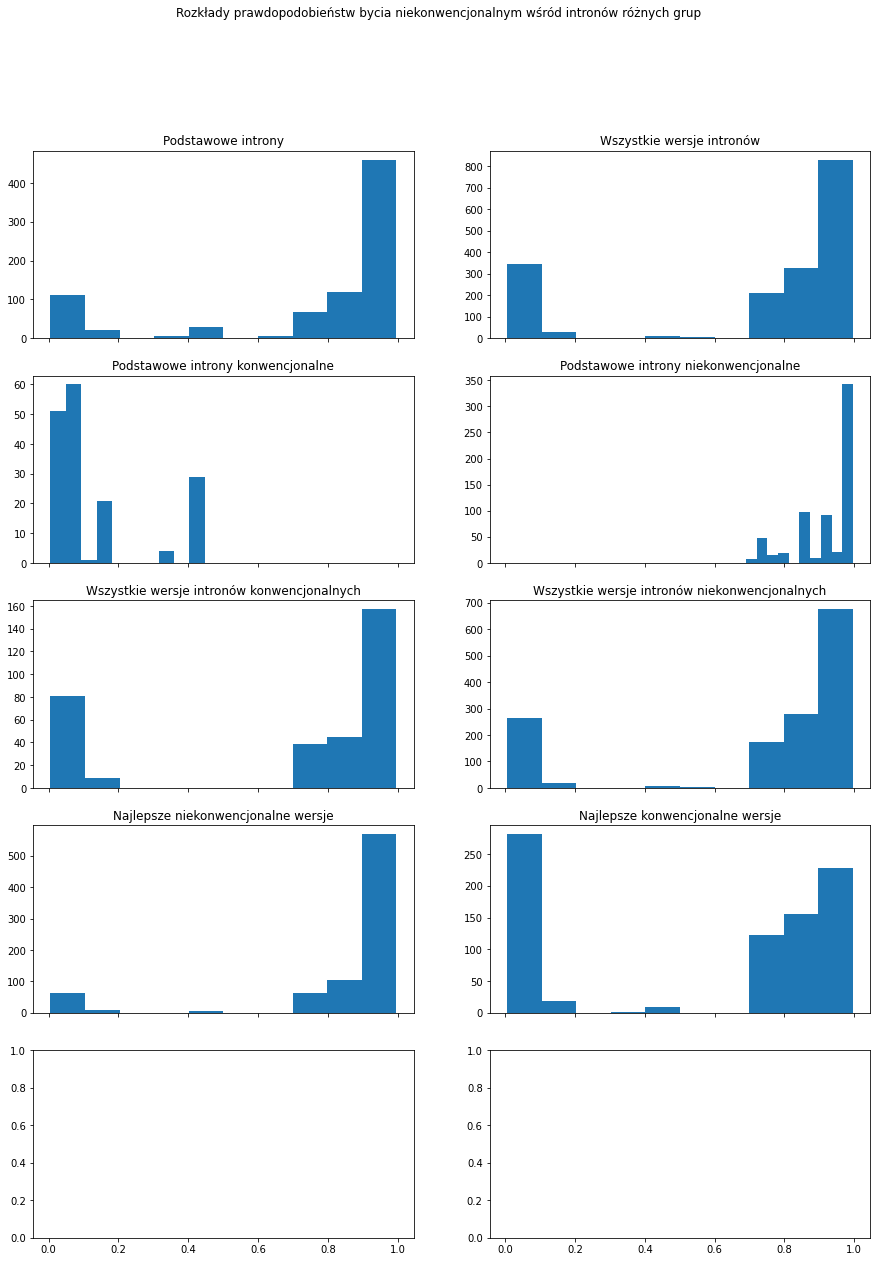

In [8]:
fig, axes = plt.subplots(5, 2, figsize=(15,20), sharex=True)
fig.suptitle("Rozkłady prawdopodobieństw bycia niekonwencjonalnym wśród intronów różnych grup")

axes[0,0].hist(podstawowe)
axes[0,0].set_title("Podstawowe introny")

axes[0,1].hist(wszystkie_wersje)
axes[0,1].set_title("Wszystkie wersje intronów")

axes[1,0].hist(podstawowe_konw)
axes[1,0].set_title("Podstawowe introny konwencjonalne")

axes[1,1].hist(podstawowe_niekonw)
axes[1,1].set_title("Podstawowe introny niekonwencjonalne")

axes[2,0].hist(wszystkie_wersje_konw)
axes[2,0].set_title("Wszystkie wersje intronów konwencjonalnych")

axes[2,1].hist(wszystkie_wersje_niekonw)
axes[2,1].set_title("Wszystkie wersje intronów niekonwencjonalnych")

axes[3,0].hist(najlepsze_nconv_wersje)
axes[3,0].set_title("Najlepsze niekonwencjonalne wersje")

axes[3,1].hist(najlepsze_conv_wersje)
axes[3,1].set_title("Najlepsze konwencjonalne wersje")

#axes[4,0].hist(wersje_niekonwencjonalne)
#axes[4,0].set_title("Wersje w niekonwencjonalnych")

#axes[4,1].hist(wersje_konwencjonalne)
#axes[4,1].set_title("Wersje w konwencjonalnych")

plt.show()